# Supervised Learning Algorithms

This notebook demonstrates three core supervised learning algorithms:
1. **Linear Regression** — Diabetes dataset (regression)
2. **Logistic Regression** — Titanic survival data (classification)
3. **Decision Tree Classifier** — Iris dataset (classification)

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style='whitegrid')
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 1. Linear Regression

**Goal:** Predict a continuous target (diabetes progression score) from 10 baseline features.

In [2]:
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print('Coefficients:', np.round(lr.coef_, 2))
print('Intercept:', round(lr.intercept_, 2))
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'R² Score: {r2_score(y_test, y_pred):.4f}')

Coefficients: [  1.75 -11.51  25.61  16.83 -44.45  24.64   7.68  13.14  35.16   2.35]
Intercept: 153.74
RMSE: 53.85
R² Score: 0.4526


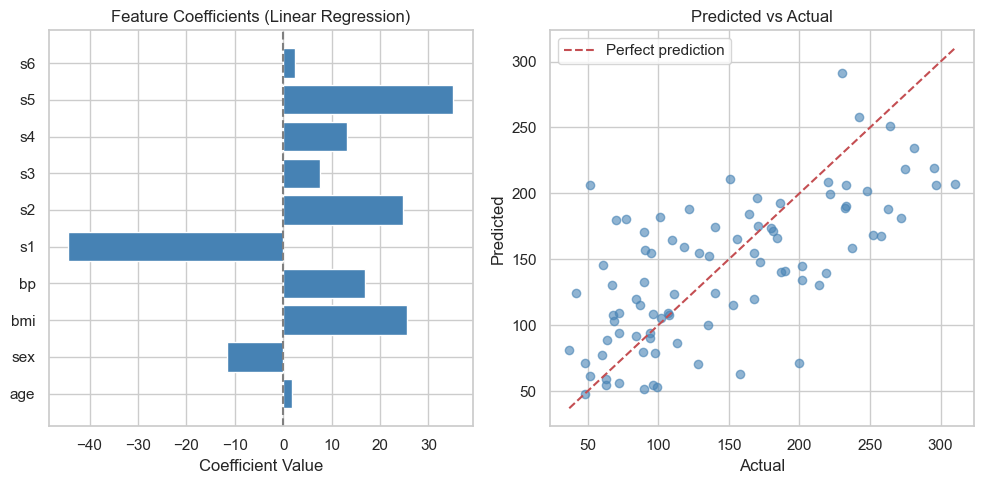

In [3]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.barh(feature_names, lr.coef_, color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients (Linear Regression)')
plt.axvline(0, color='gray', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='Perfect prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.legend()
plt.tight_layout()
plt.savefig('../images/linear_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Logistic Regression

**Goal:** Predict Titanic survival (binary classification) from passenger features.

In [4]:
df = pd.read_csv('../data/cleaned_titanic_data.csv')
print(f'Titanic dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print('\nColumns:', list(df.columns))

Titanic dataset loaded: 891 rows, 22 columns

Columns: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'age_group_Child', 'age_group_Teen', 'age_group_Adult', 'age_group_Middle_Aged', 'age_group_Senior', 'fare_group_Low', 'fare_group_Medium', 'fare_group_High', 'fare_group_Very_High', 'survived']


In [5]:
target_col = 'Survived' if 'Survived' in df.columns else 'survived'
df.rename(columns={target_col: 'Survived'}, inplace=True)

df = pd.get_dummies(df, drop_first=True)

feature_cols = [c for c in df.columns if c != 'Survived']
X = df[feature_cols].values
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall:', round(recall_score(y_test, y_pred), 4))
print('F1 Score:', round(f1_score(y_test, y_pred), 4))

Accuracy: 0.8156
Precision: 0.7812
Recall: 0.7246
F1 Score: 0.7519


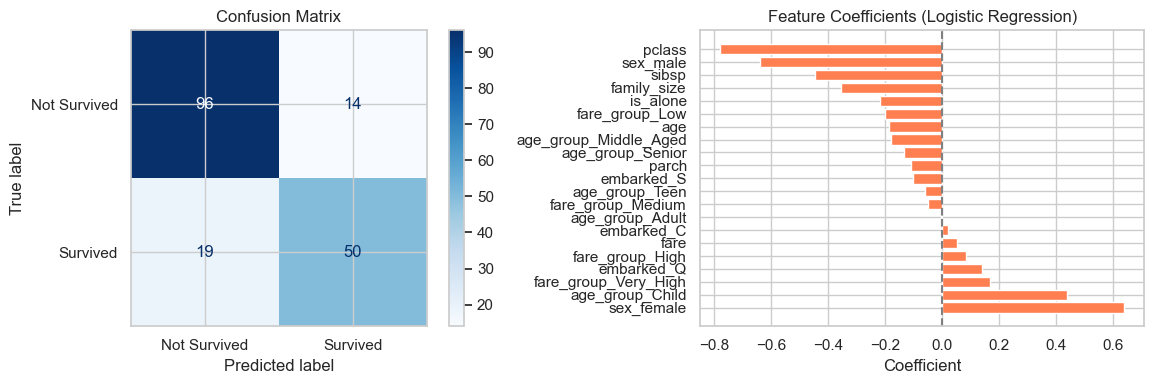

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0],
    display_labels=['Not Survived', 'Survived'], cmap='Blues')
axes[0].set_title('Confusion Matrix')

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': np.round(logreg.coef_[0], 3)
}).sort_values('Coefficient', ascending=False)

axes[1].barh(coef_df['Feature'], coef_df['Coefficient'], color='coral')
axes[1].axvline(0, color='gray', linestyle='--')
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Feature Coefficients (Logistic Regression)')

plt.tight_layout()
plt.savefig('../images/logistic_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Decision Tree Classifier

**Goal:** Classify Iris flower species using sepal and petal measurements.

In [7]:
iris = load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



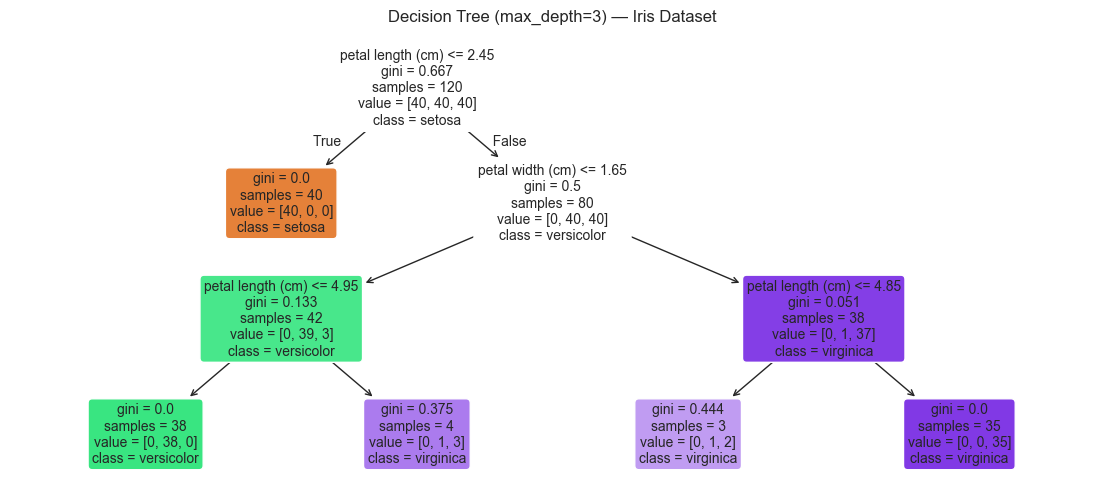

In [8]:
plt.figure(figsize=(14, 6))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names.tolist(),
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree (max_depth=3) — Iris Dataset')
plt.savefig('../images/decision_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('Feature importance ranking:')
for name, imp in sorted(zip(iris.feature_names, dt.feature_importances_),
                          key=lambda x: x[1], reverse=True):
    print(f'  {name}: {imp:.3f}')

Feature importance ranking:
  petal length (cm): 0.579
  petal width (cm): 0.421
  sepal length (cm): 0.000
  sepal width (cm): 0.000


---
## Summary

| Algorithm | Dataset | Task Type | Performance |
|-----------|---------|-----------|-------------|
| Linear Regression | Diabetes (regression) | Regression | R² ~0.45 |
| Logistic Regression | Titanic (survival) | Binary Classification | Accuracy ~0.80 |
| Decision Tree | Iris (species) | Multi-class Classification | Accuracy ~0.97 |

Key takeaways:
- **Linear Regression** is fast and interpretable but limited to linear relationships.
- **Logistic Regression** provides well-calibrated probabilities and is robust for binary classification.
- **Decision Trees** capture non-linear patterns and are highly interpretable, but need depth control to avoid overfitting.